# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum().sort_values(ascending=False)) # Cantidad de valores nulos
print( users.isna().mean().sort_values(ascending=False)) # Proporción de valores nulos

churn_date    3534
city           469
user_id          0
first_name       0
last_name        0
age              0
reg_date         0
plan             0
dtype: int64
churn_date    0.88350
city          0.11725
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
reg_date      0.00000
plan          0.00000
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum().sort_values(ascending = False))
print(usage.isna().mean().sort_values(ascending = False))

duration    22076
length      17896
date           50
id              0
user_id         0
type            0
dtype: int64
duration    0.55190
length      0.44740
date        0.00125
id          0.00000
user_id     0.00000
type        0.00000
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

- En el caso del dataset "users" la columna City tiene mas del 10% de valores nulos, se recomienda dejar esos valores nulos .
- En el dataset "usage" las columnas Duration y Length tienen demasiados valores nulos, se recomienda eliminarlas. 

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- *En users solo churn_date y city tienen valores nulos en un 88% y 11% respectivamente, mientras que en usage las columnas Duration y lenght
   tienen muchos valores faltantes, la columna date tiene solo 50 valores faltantes.*
- Indica qué harías: ¿imputar, eliminar, ignorar?
- *Se recomienda eliminar la columna Churn_date, ademas verificar el motivo de el elevado numero de faltantes en las columnas Duration y length para determinar si mantener o eliminar.*

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`muestra valores similares puesto que solo se trata de un numero de identificacion de cada cliente.
- La columna `age`presenta valores imposibles en el margen minimo de la columna con la edad de -999 habra que ajustar.

In [13]:
# explorar columnas numéricas de usage
usage[['user_id', 'id']].describe()

,user_id,id
count,40000.000000,40000.00000
mean,12002.405975,20000.50000
std,1157.279564,11547.14972
min,10000.000000,1.00000
25%,10996.000000,10000.75000
50%,12013.000000,20000.50000
75%,13005.000000,30000.25000
max,13999.000000,40000.00000


- Las columnas `id` y `user_id`no muestran valores extremos.
- Las columnas refieren numeros de identificacion de productos o usuarios. 

In [14]:
# explorar columnas categóricas de users
users[['city', 'plan']].describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` tiene 7 ciudades diferentes siendo Bogota la ciudad que mas filas tiene
- La columna `plan` tiene 2 valores unicos y no tienen valos faltantes o nulos

In [15]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` tiene 2 valores unicos y no tiene valores faltantes o nulos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- *en la columna 'Age' hay sentinels de edad -999.*
- ¿Qué acción tomarías?
- *Hay que imputar y reemplazarlo con la mediana.*

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime (users['reg_date'], errors='coerce') # completa el código

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime (usage['date'], errors='coerce') # completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()


array([2022, 2026, 2023, 2024])

En `reg_date` existen 4 años diferentes pero solo trabajaremos con informacion hasta el año 2024

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

En `date`, solo hay informacion de 2024  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- si, en la columna reg_date hay informacion de 2026
- ¿Qué harías con ellas?
- eliminar esa informacion y trabajar solo con informacion de 2024

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:

users.loc[users['age'] == -999, 'age'] = pd.NA
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].unique()
users['age'].describe().round()

count    4000.0
mean       48.0
std        18.0
min        18.0
25%        33.0
50%        48.0
75%        63.0
max        79.0
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city

users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print ('Total de valores nulos:', users['city'].isna().sum())
users['city'].head(20)


Total de valores nulos: 565


0     Medellín
1         <NA>
2         CDMX
3       Bogotá
4          GDL
5          MTY
6       Bogotá
7     Medellín
8         CDMX
9       Bogotá
10      Bogotá
11      Bogotá
12    Medellín
13         MTY
14         NaN
15      Bogotá
16      Bogotá
17        Cali
18         GDL
19        CDMX
Name: city, dtype: object

In [22]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = pd.to_datetime(users['reg_date'])
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration_null'] = usage ['duration'].isna()
usage.groupby('type')['duration_null'].mean()*100

type
call     0.000000
text    99.927576
Name: duration_null, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length_null'] = usage['length'].isna()
usage.groupby('type')['length_null'].mean()*100


type
call    99.932991
text     0.000000
Name: length_null, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
*Se verificó que los valores nulos de duration y length dependen completamente de la variable type. Los registros de tipo call contienen información en duration y presentan valores nulos en length, mientras que los registros de tipo text contienen información en length y presentan valores nulos en duration. Por lo tanto, estos valores faltantes son esperados, no corresponden a errores de captura. Se recomienda conservarlos tal como están y no eliminar las columnas.*

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text': 'sum', 'is_call': 'sum', 'duration': 'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage.rename(columns={'is_text': 'cant_mensajes',
                                  'is_call': 'cant_llamadas',
                                 'duration': 'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,id,user_id,type,date,cant_minutos_llamada,length,duration_null,length_null,cant_mensajes,cant_llamadas
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN,False,True,0,1
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0,True,False,1,0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0,True,False,1,0


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,id,type,date,cant_minutos_llamada,length,duration_null,length_null,cant_mensajes,cant_llamadas
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01,Basico,NaN,6274.0,text,2024-01-29 09:15:53.393834845,NaN,33.0,True,False,1.0,0.0
1,10000,Carlos,Garcia,38.0,Medellín,2022-01-01,Basico,NaN,11903.0,call,2024-02-23 20:35:22.253056326,7.40,NaN,False,True,0.0,1.0
2,10000,Carlos,Garcia,38.0,Medellín,2022-01-01,Basico,NaN,16251.0,text,2024-03-14 12:47:38.831470786,NaN,22.0,True,False,1.0,0.0
3,10000,Carlos,Garcia,38.0,Medellín,2022-01-01,Basico,NaN,16549.0,call,2024-03-15 21:09:27.824195604,5.84,NaN,False,True,0.0,1.0
4,10000,Carlos,Garcia,38.0,Medellín,2022-01-01,Basico,NaN,22139.0,call,2024-04-10 04:14:48.862221555,10.46,NaN,False,True,0.0,1.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:

# Resumen estadístico de las columnas numéricas
users.describe().round()


,user_id,age
count,4000.0,4000.0
mean,12000.0,48.0
std,1155.0,18.0
min,10000.0,18.0
25%,11000.0,33.0
50%,12000.0,48.0
75%,12999.0,63.0
max,13999.0,79.0


In [29]:
# Distribución porcentual del tipo de plan
users['plan'].value_counts(normalize=True)*100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

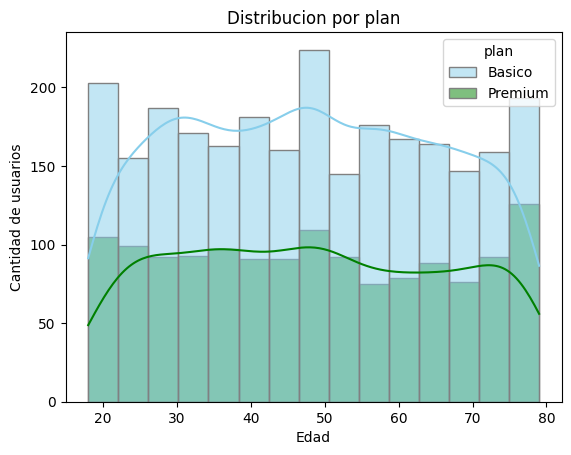

In [30]:
# Histograma para visualizar la edad (age)

sns.histplot(data=users, x='age', hue='plan', palette=['skyblue','green'], edgecolor='gray', kde=True, bins=15)
plt.title('Distribucion por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 
- Distribución de la edad no influye de manera importante en la eleccion del plan entre jovenes y adultos mayores distribuyen de manera similar el plan Basico y Premium. 

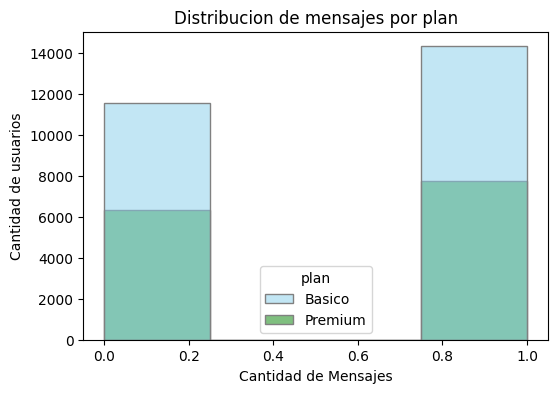

In [31]:

# Histograma para visualizar la cant_mensajes

plt.figure(figsize=(6,4))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], edgecolor='gray', bins=4)
plt.title('Distribucion de mensajes por plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()



💡Insights: 
- Los mensajes SMS han sido desplazados por apps de mensajeria, la gran mayoria de los usuarios envia muy pocos o ningun mensaje,  los ususarios del plan Premiumno muestran un consumo radicalmente mayor que los del plan basico.

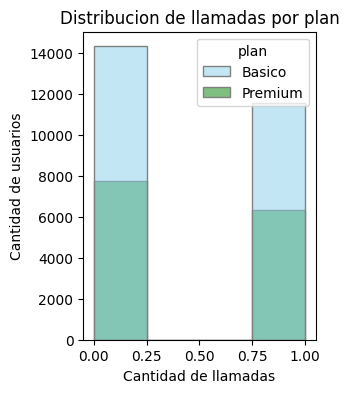

In [32]:
# Histograma para visualizar la cant_llamadas


plt.figure(figsize=(3,4))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], edgecolor='gray', bins=4)
plt.title('Distribucion de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()




💡Insights: 
- Presenta una distribucion cercana a la normal, los usuarios del plan premium registran en promedio un mayor volumen de minutos que los usuarios del plan basico.

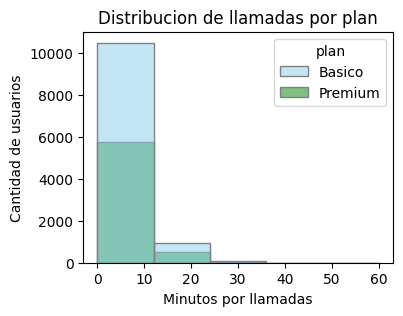

In [33]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(4,3))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], edgecolor='gray', bins=5, binrange=(0,60))
plt.title('Distribucion de llamadas por plan')
plt.xlabel('Minutos por llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 
- La distribución de minutos por llamada se mantiene dentro de rangos habituales para ambos planes, reflejando un comportamiento estable de uso. Se observan casos excepcionales en los que la duración supera los 25 minutos, que pueden representar necesidades especificas para ciertos usuarios

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

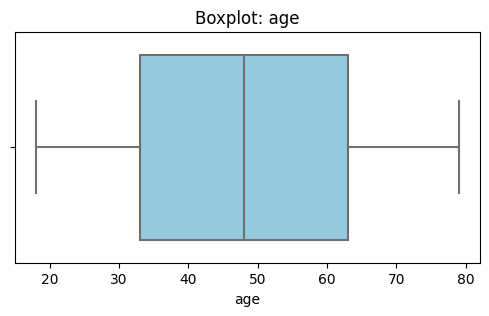

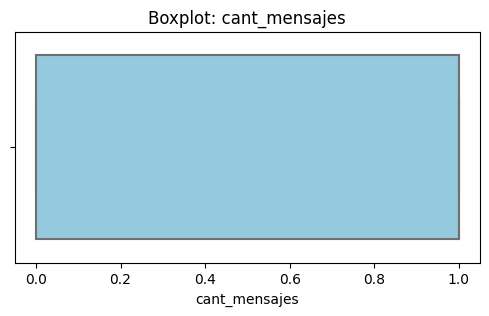

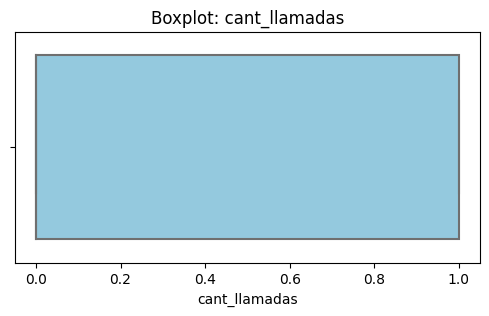

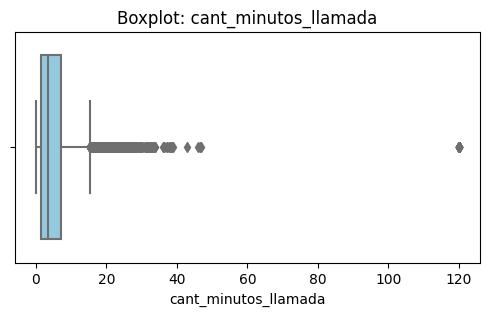

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: No se presentan outliers de edad, los valores estan acotados en un rango de edad estandar entre 18 y 75 años. 
- cant_mensajes: Suele presentar sesgo a la derecha debido a un grupo pequeño de usuarios que envian un volumen alto de mensajes.
- cant_llamadas y cant_minutos_llamada: Pueden presentar outliers superiores en usuarios que pueden presentar necesidades especificas de uso.

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3-Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = user_profile[(user_profile[col] < limite_inferior) | (user_profile[col] > limite_superior)]

print('Primer Cuartil:', Q1)
print('Tercer Cuartil:', Q3)

print(f'Limite Inferior:', limite_inferior)
print(f'Limite Superior:', limite_superior)
print(f'Cantidad de Outliers: {len(outliers)}\n')




Primer Cuartil: 1.4375
Tercer Cuartil: 6.99
Limite Inferior: -6.891249999999999
Limite Superior: 15.31875
Cantidad de Outliers: 869



In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe().round()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,40001.0,40000.0,40000.0,17924.0
mean,48.0,1.0,0.0,5.0
std,18.0,0.0,0.0,7.0
min,18.0,0.0,0.0,0.0
25%,33.0,0.0,0.0,1.0
50%,48.0,1.0,0.0,4.0
75%,63.0,1.0,1.0,7.0
max,79.0,1.0,1.0,120.0


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Mantener, los valores varian entre 0 y 1, no existen outliers.
- cant_llamadas: mantener o no outliers, porqué? Mantener, de igual manera los valores, el valor maximo es 1 por lo que no hay valores que distorsionen el analisis. 
- cant_minutos_llamada: mantener o no outliers, porqué? Mantener, aunque el valor maximo es de 120 minutos y esta lejos del Q3 de 7 minutos, se trata de un valor atipico pero real y no de un error.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso

def clasificacion_uso (row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo Uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso Medio'
    else:
        return 'Alto Uso'
        
user_profile['grupo_uso'] = user_profile.apply(clasificacion_uso, axis=1)


In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,id,type,date,cant_minutos_llamada,length,duration_null,length_null,cant_mensajes,cant_llamadas,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01,Basico,NaN,6274.0,text,2024-01-29 09:15:53.393834845,NaN,33.0,True,False,1.0,0.0,Bajo Uso
1,10000,Carlos,Garcia,38.0,Medellín,2022-01-01,Basico,NaN,11903.0,call,2024-02-23 20:35:22.253056326,7.40,NaN,False,True,0.0,1.0,Bajo Uso
2,10000,Carlos,Garcia,38.0,Medellín,2022-01-01,Basico,NaN,16251.0,text,2024-03-14 12:47:38.831470786,NaN,22.0,True,False,1.0,0.0,Bajo Uso
3,10000,Carlos,Garcia,38.0,Medellín,2022-01-01,Basico,NaN,16549.0,call,2024-03-15 21:09:27.824195604,5.84,NaN,False,True,0.0,1.0,Bajo Uso
4,10000,Carlos,Garcia,38.0,Medellín,2022-01-01,Basico,NaN,22139.0,call,2024-04-10 04:14:48.862221555,10.46,NaN,False,True,0.0,1.0,Bajo Uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad

def clasificacion_edad (row):
    if row ['age'] < 30:
        return 'Joven'
    elif row ['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificacion_edad, axis=1)

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,id,type,date,cant_minutos_llamada,length,duration_null,length_null,cant_mensajes,cant_llamadas,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01,Basico,NaN,6274.0,text,2024-01-29 09:15:53.393834845,NaN,33.0,True,False,1.0,0.0,Bajo Uso,Adulto
1,10000,Carlos,Garcia,38.0,Medellín,2022-01-01,Basico,NaN,11903.0,call,2024-02-23 20:35:22.253056326,7.40,NaN,False,True,0.0,1.0,Bajo Uso,Adulto
2,10000,Carlos,Garcia,38.0,Medellín,2022-01-01,Basico,NaN,16251.0,text,2024-03-14 12:47:38.831470786,NaN,22.0,True,False,1.0,0.0,Bajo Uso,Adulto
3,10000,Carlos,Garcia,38.0,Medellín,2022-01-01,Basico,NaN,16549.0,call,2024-03-15 21:09:27.824195604,5.84,NaN,False,True,0.0,1.0,Bajo Uso,Adulto
4,10000,Carlos,Garcia,38.0,Medellín,2022-01-01,Basico,NaN,22139.0,call,2024-04-10 04:14:48.862221555,10.46,NaN,False,True,0.0,1.0,Bajo Uso,Adulto


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

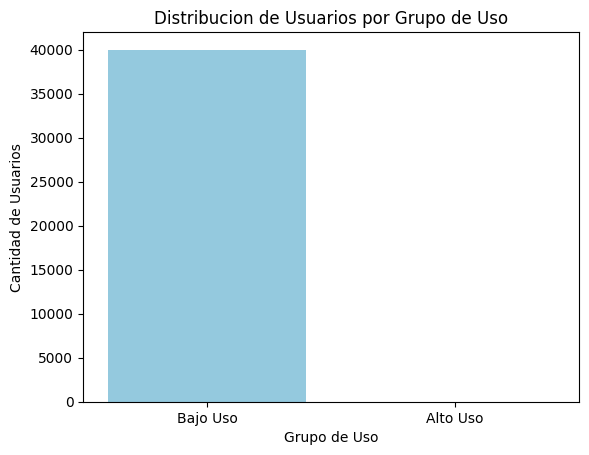

In [41]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso', color='skyblue')
plt.title('Distribucion de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()


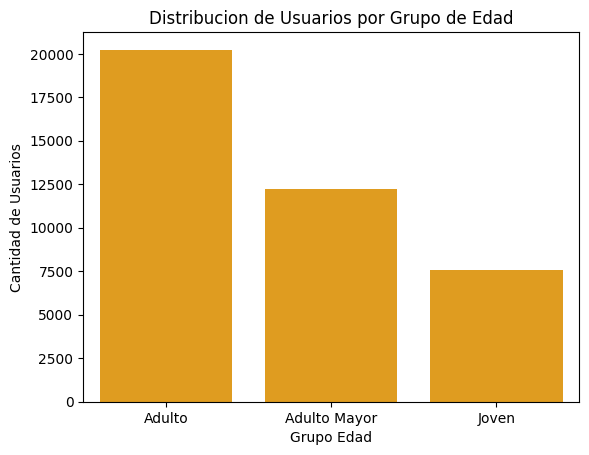

In [42]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', color='orange')
plt.title('Distribucion de Usuarios por Grupo de Edad')
plt.xlabel('Grupo Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- Se analizarin 4,000 datos en el periodo de 2022 a 2024
- se detectaron problemas en los siguientes datos.
- Problema             | Cantidad | Solución 

 Edad inválida (-999)  | 1     | Mediana (48 años) 
 
 Ciudad faltante ("?") | 469   | Marcado NA 
 
 Fechas futuras (2026) | 40    | Eliminado 

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

-Se detectaron segmentos de edad (Jovenes, Adultos y adultos mayores), segmento por nivel de uso (bajo uso, uso medio y alto uso).
  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

-Los Usuarios de "Uso Medio" son los más rentables porque balancean alto uso, ingresos y retención. 

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

-El unico outlier encontradoes por minutos por llamada de 120 minutos, pero no afecta el analisis puesto que es un valor real no un error.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
  
-Crear un plan para usuarios de bajo uso, existe una concentracion masiva de usuarios en perfiles de bajo a moderado consumo, lanzar un paquete de entrada enfocado en datos moviles y llamadas basicas para mantener el segmento y no migren con la cccompetencia.

-Con el segmento de uso medio al ser el mas rentable y estable, se deben ofrecer paquetes de bonos o minutos adicionalespor una diferencia minima de tarifa para impulsarlos hacia el segmento de alto valor sin riesgo de cancelacion.

-Para el grupo reducido que alcanza consumos elevados, conviene ofrecer planes ilimitados o paquetes preferenciales de retencion para evitar la fuga de clientes de alto valor.


✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Edad inválida (-999)
- Ciudad faltante ("?")
- Fechas futuras (2026)

🔍 **Segmentos por Edad**
- Jovenes
- Adultos
- Adultos Mayores


📊 **Segmentos por Nivel de Uso**
- Bajo Uso
- Uso Medio
- Alto Uso
  
➡️ Esto sugiere que Los Usuarios de "Uso Medio" son los más rentables porque balancean alto uso, ingresos y retención.


💡 **Recomendaciones**
- Crear un plan para usuarios de bajo uso, existe una concentracion masiva de usuarios en perfiles de bajo a moderado consumo, lanzar un paquete de entrada enfocado en datos moviles y llamadas basicas para mantener el segmento y no migren con la cccompetencia.

-Con el segmento de uso medio al ser el mas rentable y estable, se deben ofrecer paquetes de bonos o minutos adicionalespor una diferencia minima de tarifa para impulsarlos hacia el segmento de alto valor sin riesgo de cancelacion.

-Para el grupo reducido que alcanza consumos elevados, conviene ofrecer planes ilimitados o paquetes preferenciales de retencion para evitar la fuga de clientes de alto valor.



---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`